# Modellierung & Evaluation – Lebensmittelpreisprognose

**Ziel:** Vorhersage von Lebensmittelpreisindizes mit drei ML-Modellen (Random Forest, XGBoost, Facebook Prophet) und systematischer Vergleich der Ergebnisse.

**Datengrundlage:** Aufbereitete Destatis-Daten (`features_destatis.csv`) mit 168 Produkten, ~65 Monaten und vorberechneten Zeitreihen-Features (Lags, Rolling Means).

## 1. Setup & Imports

In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Setup abgeschlossen.")

Setup abgeschlossen.


## 2. Daten laden & vorbereiten

In [109]:
df = pd.read_csv('data_processed/features_destatis.csv', parse_dates=['Datum'])

print(f"Shape: {df.shape}")
print(f"Produkte: {df['Produkt'].nunique()}")
print(f"Zeitraum: {df['Datum'].min().date()} – {df['Datum'].max().date()}")
print(f"\nSpalten: {list(df.columns)}")
print(f"\nNaN pro Spalte:\n{df.isnull().sum()}")
print(f"\nRisikogruppen:\n{df['Risikogruppe'].value_counts()}")
df.head()

Shape: (11046, 13)
Produkte: 168
Zeitraum: 2020-01-01 – 2025-06-01

Spalten: ['COICOP-Index', 'Produkt', 'Monat', 'Preisindex', 'Monat_Nr', 'lag_1', 'lag_2', 'lag_3', 'rolling_mean_3', 'rolling_mean_6', 'Datum', 'Risikogruppe', 'preisanstieg_pct']

NaN pro Spalte:
COICOP-Index           0
Produkt                0
Monat                  0
Preisindex             0
Monat_Nr             168
lag_1                168
lag_2                336
lag_3                504
rolling_mean_3       504
rolling_mean_6      1008
Datum                168
Risikogruppe           0
preisanstieg_pct       0
dtype: int64

Risikogruppen:
Risikogruppe
hoch      3783
stabil    3656
mittel    3607
Name: count, dtype: int64


,COICOP-Index,Produkt,Monat,Preisindex,Monat_Nr,lag_1,lag_2,lag_3,rolling_mean_3,rolling_mean_6,Datum,Risikogruppe,preisanstieg_pct
0,CC13-0116403100,"Ananaskonserve, Erdbeerkonserve oder Ähnliches",Januar,99.3,1.0,NaN,NaN,NaN,NaN,NaN,2020-01-01,hoch,62.336354
1,CC13-0116403100,"Ananaskonserve, Erdbeerkonserve oder Ähnliches",Februar,99.5,2.0,99.3,NaN,NaN,NaN,NaN,2020-02-01,hoch,62.336354
2,CC13-0116403100,"Ananaskonserve, Erdbeerkonserve oder Ähnliches",März,99.9,3.0,99.5,99.3,NaN,NaN,NaN,2020-03-01,hoch,62.336354
3,CC13-0116403100,"Ananaskonserve, Erdbeerkonserve oder Ähnliches",April,100.1,4.0,99.9,99.5,99.3,99.566667,NaN,2020-04-01,hoch,62.336354
4,CC13-0116403100,"Ananaskonserve, Erdbeerkonserve oder Ähnliches",Mai,100.5,5.0,100.1,99.9,99.5,99.833333,NaN,2020-05-01,hoch,62.336354


### 2.1 NaN-Handling & Feature-Vorbereitung

Die ersten Monate pro Produkt haben keine Lag-/Rolling-Werte (strukturelle NaNs). Wir entfernen diese Zeilen, da eine Imputation bei Zeitreihen-Lags keinen Sinn ergibt – die Information existiert schlicht noch nicht.

In [110]:
feature_cols = ['Monat_Nr', 'lag_1', 'lag_2', 'lag_3', 'rolling_mean_3', 'rolling_mean_6']
target_col = 'Preisindex'

print(f"Zeilen vor dropna: {len(df)}")
df_clean = df.dropna(subset=feature_cols + [target_col]).copy()
print(f"Zeilen nach dropna: {len(df_clean)} (entfernt: {len(df) - len(df_clean)})")

# Saisonalitäts-Features: sin/cos-Transformation des Monats (zyklisch)
df_clean['Monat_Num'] = df_clean['Datum'].dt.month
df_clean['Monat_sin'] = np.sin(2 * np.pi * df_clean['Monat_Num'] / 12)
df_clean['Monat_cos'] = np.cos(2 * np.pi * df_clean['Monat_Num'] / 12)

# Produkt als numerisches Feature (Label-Encoding)
le_produkt = LabelEncoder()
df_clean['Produkt_encoded'] = le_produkt.fit_transform(df_clean['Produkt'])

# Risikogruppe als numerisches Feature
le_risiko = LabelEncoder()
df_clean['Risiko_encoded'] = le_risiko.fit_transform(df_clean['Risikogruppe'])

print(f"\nNeue Features hinzugefügt: Monat_sin, Monat_cos, Produkt_encoded, Risiko_encoded")
print(f"Finale Shape: {df_clean.shape}")
df_clean.head()

Zeilen vor dropna: 11046
Zeilen nach dropna: 9870 (entfernt: 1176)

Neue Features hinzugefügt: Monat_sin, Monat_cos, Produkt_encoded, Risiko_encoded
Finale Shape: (9870, 18)


,COICOP-Index,Produkt,Monat,Preisindex,Monat_Nr,lag_1,lag_2,lag_3,rolling_mean_3,rolling_mean_6,Datum,Risikogruppe,preisanstieg_pct,Monat_Num,Monat_sin,Monat_cos,Produkt_encoded,Risiko_encoded
6,CC13-0116403100,"Ananaskonserve, Erdbeerkonserve oder Ähnliches",Juli,98.4,7.0,100.7,100.5,100.1,100.433333,100.000000,2020-07-01,hoch,62.336354,7,-0.500000,-8.660254e-01,0,0
7,CC13-0116403100,"Ananaskonserve, Erdbeerkonserve oder Ähnliches",August,98.7,8.0,98.4,100.7,100.5,99.866667,99.850000,2020-08-01,hoch,62.336354,8,-0.866025,-5.000000e-01,0,0
8,CC13-0116403100,"Ananaskonserve, Erdbeerkonserve oder Ähnliches",September,99.5,9.0,98.7,98.4,100.7,99.266667,99.716667,2020-09-01,hoch,62.336354,9,-1.000000,-1.836970e-16,0,0
9,CC13-0116403100,"Ananaskonserve, Erdbeerkonserve oder Ähnliches",Oktober,99.9,10.0,99.5,98.7,98.4,98.866667,99.650000,2020-10-01,hoch,62.336354,10,-0.866025,5.000000e-01,0,0
10,CC13-0116403100,"Ananaskonserve, Erdbeerkonserve oder Ähnliches",November,101.1,11.0,99.9,99.5,98.7,99.366667,99.616667,2020-11-01,hoch,62.336354,11,-0.500000,8.660254e-01,0,0


### 2.2 Train/Test-Split (zeitlich korrekt)

Bei Zeitreihen darf **kein zufälliger Split** verwendet werden – das würde Data Leakage verursachen, da das Modell zukünftige Informationen zum Training nutzen könnte. Stattdessen verwenden wir einen zeitlichen Cutoff: die letzten 6 Monate als Testset.

In [111]:
# Zeitlichen Cutoff bestimmen: letzte 6 Monate = Testset
sorted_dates = sorted(df_clean['Datum'].unique())
cutoff_date = sorted_dates[-6]  # 6 Monate vor dem letzten Datum

train = df_clean[df_clean['Datum'] < cutoff_date].copy()
test = df_clean[df_clean['Datum'] >= cutoff_date].copy()

print(f"Cutoff-Datum: {pd.Timestamp(cutoff_date).date()}")
print(f"Train: {len(train)} Zeilen ({train['Datum'].min().date()} – {train['Datum'].max().date()})")
print(f"Test:  {len(test)} Zeilen ({test['Datum'].min().date()} – {test['Datum'].max().date()})")
print(f"Train-Produkte: {train['Produkt'].nunique()}, Test-Produkte: {test['Produkt'].nunique()}")

# Features für RF und XGBoost
ml_features = ['Monat_Nr', 'lag_1', 'lag_2', 'lag_3', 'rolling_mean_3', 'rolling_mean_6',
               'Monat_sin', 'Monat_cos', 'Produkt_encoded']

X_train = train[ml_features]
y_train = train[target_col]
X_test = test[ml_features]
y_test = test[target_col]

print(f"\nFeature-Matrix: X_train {X_train.shape}, X_test {X_test.shape}")

Cutoff-Datum: 2025-01-01
Train: 9072 Zeilen (2020-07-01 – 2024-12-01)
Test:  798 Zeilen (2025-01-01 – 2025-06-01)
Train-Produkte: 168, Test-Produkte: 133

Feature-Matrix: X_train (9072, 9), X_test (798, 9)


## 3. Modell 1: Random Forest Regression

Random Forest ist ein Ensemble-Verfahren, das viele Entscheidungsbäume parallel trainiert und deren Vorhersagen mittelt. Es ist robust gegenüber Overfitting und liefert interpretierbare Feature-Importance-Werte.

### 3.1 Baseline-Modell

In [112]:
rf_baseline = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf_baseline.fit(X_train, y_train)

y_pred_rf_base = rf_baseline.predict(X_test)

print("=== Random Forest Baseline ===")
print(f"RMSE:  {np.sqrt(mean_squared_error(y_test, y_pred_rf_base)):.4f}")
print(f"MAE:   {mean_absolute_error(y_test, y_pred_rf_base):.4f}")
print(f"R²:    {r2_score(y_test, y_pred_rf_base):.4f}")
print(f"MAPE:  {mean_absolute_percentage_error(y_test, y_pred_rf_base):.4f}")

=== Random Forest Baseline ===
RMSE:  4.3961
MAE:   2.2742
R²:    0.9227
MAPE:  0.0167


### 3.2 Hyperparameter-Tuning

In [113]:
rf_param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

tscv = TimeSeriesSplit(n_splits=3)

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=20,
    cv=tscv,
    scoring='neg_mean_squared_error',
    random_state=RANDOM_STATE,
    verbose=1
)

rf_search.fit(X_train, y_train)

print(f"\nBeste Parameter: {rf_search.best_params_}")
print(f"Bester CV-RMSE: {np.sqrt(-rf_search.best_score_):.4f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Beste Parameter: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 20}
Bester CV-RMSE: 4.6029


In [114]:
rf_best = rf_search.best_estimator_
y_pred_rf = rf_best.predict(X_test)

print("=== Random Forest (Tuned) ===")
print(f"RMSE:  {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.4f}")
print(f"MAE:   {mean_absolute_error(y_test, y_pred_rf):.4f}")
print(f"R²:    {r2_score(y_test, y_pred_rf):.4f}")
print(f"MAPE:  {mean_absolute_percentage_error(y_test, y_pred_rf):.4f}")

=== Random Forest (Tuned) ===
RMSE:  4.2494
MAE:   2.2199
R²:    0.9278
MAPE:  0.0163


### 3.3 Feature Importance (Random Forest)

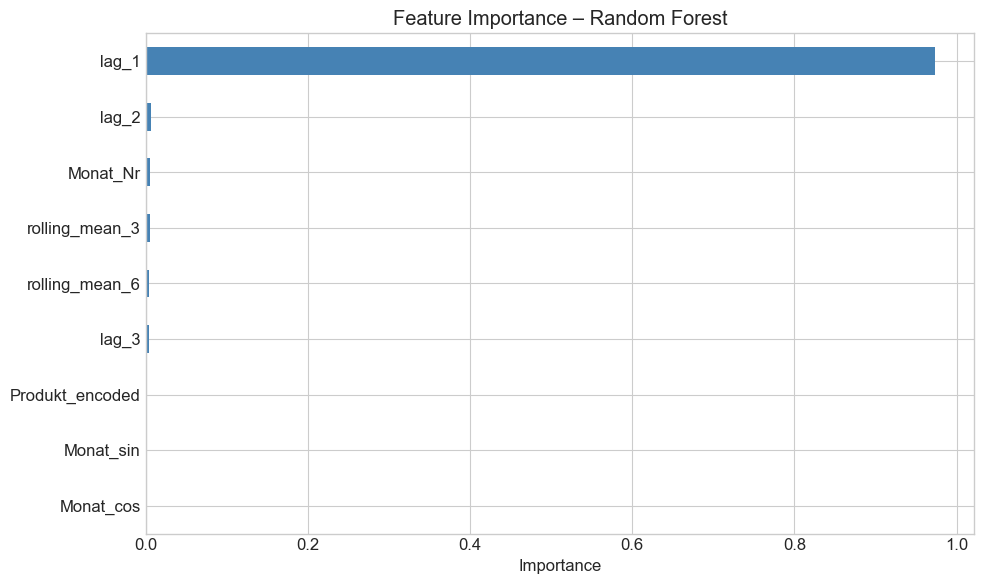

In [115]:
rf_importance = pd.Series(rf_best.feature_importances_, index=ml_features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
rf_importance.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importance – Random Forest')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## 4. Modell 2: Gradient Boosting (XGBoost)

XGBoost (Extreme Gradient Boosting) baut Bäume sequenziell auf, wobei jeder neue Baum die Fehler des vorherigen korrigiert. Es bietet Regularisierung und Early Stopping und erzielt häufig die höchste Genauigkeit bei tabellarischen Daten.

### 4.1 Baseline-Modell

In [116]:
xgb_baseline = xgb.XGBRegressor(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0
)
xgb_baseline.fit(X_train, y_train)

y_pred_xgb_base = xgb_baseline.predict(X_test)

print("=== XGBoost Baseline ===")
print(f"RMSE:  {np.sqrt(mean_squared_error(y_test, y_pred_xgb_base)):.4f}")
print(f"MAE:   {mean_absolute_error(y_test, y_pred_xgb_base):.4f}")
print(f"R²:    {r2_score(y_test, y_pred_xgb_base):.4f}")
print(f"MAPE:  {mean_absolute_percentage_error(y_test, y_pred_xgb_base):.4f}")

=== XGBoost Baseline ===
RMSE:  4.4342
MAE:   2.3481
R²:    0.9214
MAPE:  0.0172


### 4.2 Hyperparameter-Tuning mit Early Stopping

In [117]:
xgb_param_dist = {
    'n_estimators': [200, 300, 500, 800],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 10],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'reg_alpha': [0, 0.1, 1.0],
    'reg_lambda': [1.0, 2.0, 5.0],
}

xgb_search = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbosity=0, early_stopping_rounds=20),
    param_distributions=xgb_param_dist,
    n_iter=30,
    cv=tscv,
    scoring='neg_mean_squared_error',
    random_state=RANDOM_STATE,
    verbose=1
)

xgb_search.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

print(f"\nBeste Parameter: {xgb_search.best_params_}")
print(f"Bester CV-RMSE: {np.sqrt(-xgb_search.best_score_):.4f}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits

Beste Parameter: {'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 0.1, 'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.2, 'colsample_bytree': 0.9}
Bester CV-RMSE: 4.7562


In [118]:
xgb_best = xgb_search.best_estimator_
y_pred_xgb = xgb_best.predict(X_test)

print("=== XGBoost (Tuned) ===")
print(f"RMSE:  {np.sqrt(mean_squared_error(y_test, y_pred_xgb)):.4f}")
print(f"MAE:   {mean_absolute_error(y_test, y_pred_xgb):.4f}")
print(f"R²:    {r2_score(y_test, y_pred_xgb):.4f}")
print(f"MAPE:  {mean_absolute_percentage_error(y_test, y_pred_xgb):.4f}")

=== XGBoost (Tuned) ===
RMSE:  4.3147
MAE:   2.3140
R²:    0.9256
MAPE:  0.0169


### 4.3 Feature Importance (XGBoost)

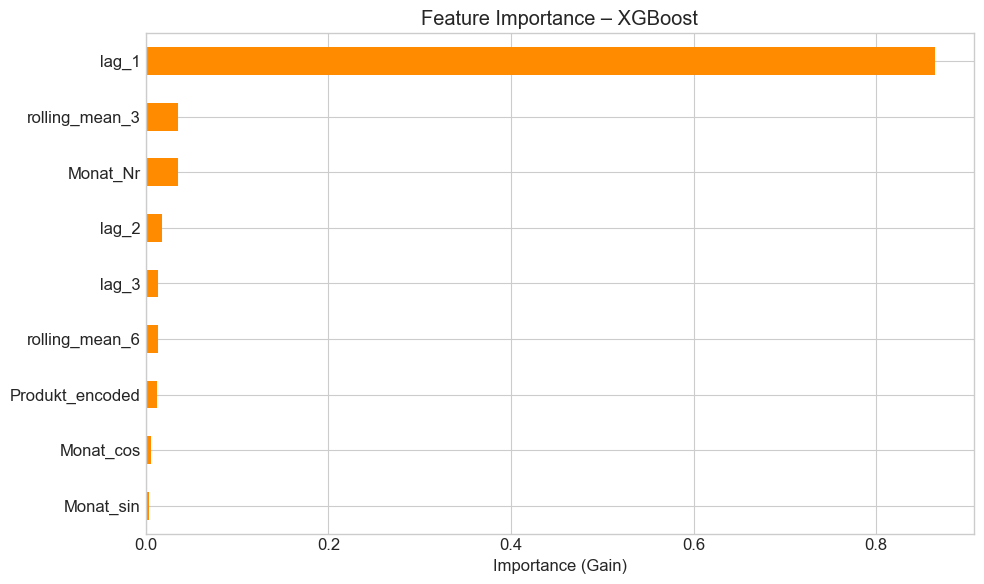

In [119]:
xgb_importance = pd.Series(xgb_best.feature_importances_, index=ml_features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
xgb_importance.plot(kind='barh', ax=ax, color='darkorange')
ax.set_title('Feature Importance – XGBoost')
ax.set_xlabel('Importance (Gain)')
plt.tight_layout()
plt.show()

## 5. Modell 3: Facebook Prophet

Prophet ist ein von Meta entwickeltes Zeitreihenmodell, das Trend, Saisonalität und Feiertage automatisch modelliert. Es wird **pro Produkt** einzeln trainiert (univariate Zeitreihe) und liefert nativ Konfidenzintervalle.

Wir wählen eine repräsentative Auswahl von Produkten aus verschiedenen Risikogruppen und trainieren Prophet-Modelle für alle Produkte, die im Testset vorhanden sind.

### 5.1 Baseline-Modell (alle Produkte mit Standard-Parametern)

In [120]:
import logging
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

prophet_results = []
prophet_forecasts = {}

test_products = test['Produkt'].unique()
print(f"Prophet: Trainiere Modelle für {len(test_products)} Produkte...")

for i, produkt in enumerate(test_products):
    df_prod = df_clean[df_clean['Produkt'] == produkt][['Datum', 'Preisindex']].copy()
    df_prod.columns = ['ds', 'y']
    
    # Train/Test-Split mit gleichem Cutoff
    prod_train = df_prod[df_prod['ds'] < cutoff_date]
    prod_test = df_prod[df_prod['ds'] >= cutoff_date]
    
    if len(prod_train) < 12 or len(prod_test) == 0:
        continue
    
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=0.05,
        seasonality_prior_scale=10.0,
    )
    model.fit(prod_train)
    
    future = model.make_future_dataframe(periods=len(prod_test), freq='MS')
    forecast = model.predict(future)
    
    # Nur Testperiode extrahieren
    forecast_test = forecast[forecast['ds'] >= pd.Timestamp(cutoff_date)]
    forecast_test = forecast_test.head(len(prod_test))
    
    if len(forecast_test) == len(prod_test):
        prophet_results.append({
            'Produkt': produkt,
            'y_true': prod_test['y'].values,
            'y_pred': forecast_test['yhat'].values,
            'y_lower': forecast_test['yhat_lower'].values,
            'y_upper': forecast_test['yhat_upper'].values,
            'dates': prod_test['ds'].values,
        })
        prophet_forecasts[produkt] = (model, forecast, prod_train, prod_test)
    
    if (i + 1) % 50 == 0:
        print(f"  {i + 1}/{len(test_products)} Produkte verarbeitet...")

print(f"\nErfolgreich trainiert: {len(prophet_results)} Produkte")

Prophet: Trainiere Modelle für 133 Produkte...
  50/133 Produkte verarbeitet...
  100/133 Produkte verarbeitet...

Erfolgreich trainiert: 133 Produkte


### 5.2 Hyperparameter-Tuning (Prophet)

Prophet bietet keine automatische Tuning-Schnittstelle wie scikit-learn (kein `RandomizedSearchCV`). Außerdem wird pro Produkt ein eigenes Modell trainiert – alle 168 Produkte × alle Parameterkombinationen zu testen wäre extrem rechenaufwendig.

**Unser Kompromiss:** Wir tunen auf einer repräsentativen Stichprobe von Produkten (je 5 pro Risikogruppe = 15 Produkte) und übertragen die besten Parameter anschließend auf alle 168 Produkte. Das ist ein gängiger Ansatz bei Prophet, da Produkte innerhalb einer Risikogruppe ähnliches Preisverhalten zeigen.

In [121]:
# =============================================================================
# Prophet Hyperparameter-Tuning
# =============================================================================
# WARUM NICHT ALLE 168 PRODUKTE TUNEN?
# - Prophet hat kein RandomizedSearchCV wie scikit-learn
# - Jede Kombination erfordert ein komplett neues Modell pro Produkt
# - 168 Produkte × 36 Kombinationen = 6.048 Modelle → viel zu langsam
#
# UNSER KOMPROMISS:
# 1. Wir wählen 15 repräsentative Produkte (5 pro Risikogruppe)
# 2. Testen verschiedene Parameterkombinationen nur auf diesen 15
# 3. Wählen die Kombination mit dem niedrigsten durchschnittlichen RMSE
# 4. Trainieren dann alle 168 Produkte mit diesen optimalen Parametern
#
# WARUM FUNKTIONIERT DAS?
# Produkte innerhalb einer Risikogruppe zeigen ähnliches Preisverhalten.
# Parameter, die auf einer Stichprobe gut funktionieren, generalisieren
# erfahrungsgemäß gut auf die restlichen Produkte.
# =============================================================================

# --- Schritt 1: Repräsentative Stichprobe auswählen ---
# Je 5 Produkte pro Risikogruppe, zufällig aber reproduzierbar ausgewählt
np.random.seed(RANDOM_STATE)
sample_products = []
for gruppe in ['hoch', 'mittel', 'stabil']:
    produkte_in_gruppe = df_clean[df_clean['Risikogruppe'] == gruppe]['Produkt'].unique()
    # Nur Produkte nehmen, die genug Trainingsdaten haben (mind. 12 Monate)
    valid = [p for p in produkte_in_gruppe 
             if len(df_clean[(df_clean['Produkt'] == p) & (df_clean['Datum'] < cutoff_date)]) >= 12]
    chosen = np.random.choice(valid, size=min(5, len(valid)), replace=False)
    sample_products.extend(chosen)

print(f"Tuning-Stichprobe: {len(sample_products)} Produkte (je 5 pro Risikogruppe)")

# --- Schritt 2: Parameterkombinationen definieren ---
# Die zwei wichtigsten Prophet-Parameter:
# - changepoint_prior_scale: Wie flexibel darf der Trend sein?
#     Niedrig (0.01) = starrer Trend, Hoch (0.5) = sehr flexibel
# - seasonality_prior_scale: Wie stark darf die Saisonalität schwanken?
#     Niedrig (0.1) = gedämpfte Saisonalität, Hoch (10) = starke Saisonalität
param_grid = [
    {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 0.1},
    {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 1.0},
    {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 10.0},
    {'changepoint_prior_scale': 0.05, 'seasonality_prior_scale': 0.1},
    {'changepoint_prior_scale': 0.05, 'seasonality_prior_scale': 1.0},
    {'changepoint_prior_scale': 0.05, 'seasonality_prior_scale': 10.0},
    {'changepoint_prior_scale': 0.1,  'seasonality_prior_scale': 0.1},
    {'changepoint_prior_scale': 0.1,  'seasonality_prior_scale': 1.0},
    {'changepoint_prior_scale': 0.1,  'seasonality_prior_scale': 10.0},
    {'changepoint_prior_scale': 0.3,  'seasonality_prior_scale': 0.1},
    {'changepoint_prior_scale': 0.3,  'seasonality_prior_scale': 1.0},
    {'changepoint_prior_scale': 0.3,  'seasonality_prior_scale': 10.0},
]

print(f"Teste {len(param_grid)} Parameterkombinationen auf {len(sample_products)} Produkten...")
print(f"= {len(param_grid) * len(sample_products)} Modelle (statt {len(param_grid) * len(test_products)} bei allen Produkten)\n")

# --- Schritt 3: Jede Kombination auf der Stichprobe testen ---
tuning_results = []

for idx, params in enumerate(param_grid):
    rmse_list = []
    
    for produkt in sample_products:
        df_prod = df_clean[df_clean['Produkt'] == produkt][['Datum', 'Preisindex']].copy()
        df_prod.columns = ['ds', 'y']
        
        prod_train = df_prod[df_prod['ds'] < cutoff_date]
        prod_test = df_prod[df_prod['ds'] >= cutoff_date]
        
        if len(prod_test) == 0:
            continue
        
        model = Prophet(
            yearly_seasonality=True,
            weekly_seasonality=False,
            daily_seasonality=False,
            changepoint_prior_scale=params['changepoint_prior_scale'],
            seasonality_prior_scale=params['seasonality_prior_scale'],
        )
        model.fit(prod_train)
        
        future = model.make_future_dataframe(periods=len(prod_test), freq='MS')
        forecast = model.predict(future)
        forecast_test = forecast[forecast['ds'] >= pd.Timestamp(cutoff_date)].head(len(prod_test))
        
        if len(forecast_test) == len(prod_test):
            rmse = np.sqrt(mean_squared_error(prod_test['y'].values, forecast_test['yhat'].values))
            rmse_list.append(rmse)
    
    avg_rmse = np.mean(rmse_list)
    tuning_results.append({**params, 'avg_rmse': avg_rmse, 'n_products': len(rmse_list)})
    print(f"  Kombination {idx+1}/{len(param_grid)}: "
          f"changepoint={params['changepoint_prior_scale']}, "
          f"seasonality={params['seasonality_prior_scale']} "
          f"→ Avg RMSE: {avg_rmse:.4f}")

# --- Schritt 4: Beste Parameter identifizieren ---
tuning_df = pd.DataFrame(tuning_results).sort_values('avg_rmse')
best_params = tuning_df.iloc[0]

print(f"\n{'='*60}")
print(f"BESTE PARAMETER:")
print(f"  changepoint_prior_scale = {best_params['changepoint_prior_scale']}")
print(f"  seasonality_prior_scale = {best_params['seasonality_prior_scale']}")
print(f"  Avg RMSE auf Stichprobe  = {best_params['avg_rmse']:.4f}")
print(f"{'='*60}")

Tuning-Stichprobe: 15 Produkte (je 5 pro Risikogruppe)
Teste 12 Parameterkombinationen auf 15 Produkten...
= 180 Modelle (statt 1596 bei allen Produkten)

  Kombination 1/12: changepoint=0.01, seasonality=0.1 → Avg RMSE: 14.1197
  Kombination 2/12: changepoint=0.01, seasonality=1.0 → Avg RMSE: 14.5479
  Kombination 3/12: changepoint=0.01, seasonality=10.0 → Avg RMSE: 14.5706
  Kombination 4/12: changepoint=0.05, seasonality=0.1 → Avg RMSE: 9.0243
  Kombination 5/12: changepoint=0.05, seasonality=1.0 → Avg RMSE: 9.1533
  Kombination 6/12: changepoint=0.05, seasonality=10.0 → Avg RMSE: 9.2363
  Kombination 7/12: changepoint=0.1, seasonality=0.1 → Avg RMSE: 6.1559
  Kombination 8/12: changepoint=0.1, seasonality=1.0 → Avg RMSE: 6.3826
  Kombination 9/12: changepoint=0.1, seasonality=10.0 → Avg RMSE: 6.3505
  Kombination 10/12: changepoint=0.3, seasonality=0.1 → Avg RMSE: 4.6937
  Kombination 11/12: changepoint=0.3, seasonality=1.0 → Avg RMSE: 4.8366
  Kombination 12/12: changepoint=0.3, s

### 5.3 Finales Prophet-Training (alle Produkte mit optimalen Parametern)

In [122]:
# =============================================================================
# Finales Training: Alle Produkte mit den besten Parametern aus dem Tuning
# =============================================================================
# Wir überschreiben die Baseline-Ergebnisse mit den getunten Modellen,
# damit der spätere Modellvergleich (Abschnitt 6) die optimierten
# Prophet-Ergebnisse nutzt – fair gegenüber RF und XGBoost, die ebenfalls
# getuned wurden.
# =============================================================================

best_cp = best_params['changepoint_prior_scale']
best_sp = best_params['seasonality_prior_scale']

print(f"Finales Training mit: changepoint_prior_scale={best_cp}, seasonality_prior_scale={best_sp}")
print(f"Trainiere Modelle für {len(test_products)} Produkte...\n")

# Ergebnisse neu befüllen (überschreiben die Baseline-Ergebnisse)
prophet_results = []
prophet_forecasts = {}

for i, produkt in enumerate(test_products):
    df_prod = df_clean[df_clean['Produkt'] == produkt][['Datum', 'Preisindex']].copy()
    df_prod.columns = ['ds', 'y']
    
    prod_train = df_prod[df_prod['ds'] < cutoff_date]
    prod_test = df_prod[df_prod['ds'] >= cutoff_date]
    
    if len(prod_train) < 12 or len(prod_test) == 0:
        continue
    
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=best_cp,
        seasonality_prior_scale=best_sp,
    )
    model.fit(prod_train)
    
    future = model.make_future_dataframe(periods=len(prod_test), freq='MS')
    forecast = model.predict(future)
    
    forecast_test = forecast[forecast['ds'] >= pd.Timestamp(cutoff_date)]
    forecast_test = forecast_test.head(len(prod_test))
    
    if len(forecast_test) == len(prod_test):
        prophet_results.append({
            'Produkt': produkt,
            'y_true': prod_test['y'].values,
            'y_pred': forecast_test['yhat'].values,
            'y_lower': forecast_test['yhat_lower'].values,
            'y_upper': forecast_test['yhat_upper'].values,
            'dates': prod_test['ds'].values,
        })
        prophet_forecasts[produkt] = (model, forecast, prod_train, prod_test)
    
    if (i + 1) % 50 == 0:
        print(f"  {i + 1}/{len(test_products)} Produkte verarbeitet...")

print(f"\nErfolgreich trainiert: {len(prophet_results)} Produkte (mit getunten Parametern)")

Finales Training mit: changepoint_prior_scale=0.3, seasonality_prior_scale=0.1
Trainiere Modelle für 133 Produkte...

  50/133 Produkte verarbeitet...
  100/133 Produkte verarbeitet...

Erfolgreich trainiert: 133 Produkte (mit getunten Parametern)


In [123]:
# Prophet-Metriken aggregieren
prophet_y_true = np.concatenate([r['y_true'] for r in prophet_results])
prophet_y_pred = np.concatenate([r['y_pred'] for r in prophet_results])

print("=== Facebook Prophet (Aggregiert über alle Produkte) ===")
print(f"RMSE:  {np.sqrt(mean_squared_error(prophet_y_true, prophet_y_pred)):.4f}")
print(f"MAE:   {mean_absolute_error(prophet_y_true, prophet_y_pred):.4f}")
print(f"R²:    {r2_score(prophet_y_true, prophet_y_pred):.4f}")
print(f"MAPE:  {mean_absolute_percentage_error(prophet_y_true, prophet_y_pred):.4f}")

=== Facebook Prophet (Aggregiert über alle Produkte) ===
RMSE:  6.7369
MAE:   4.0665
R²:    0.8185
MAPE:  0.0293


## 6. Modellvergleich & Evaluation

### 6.1 Vergleichstabelle

In [124]:
def calc_metrics(y_true, y_pred, name):
    return {
        'Modell': name,
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'R²': r2_score(y_true, y_pred),
        'MAPE': mean_absolute_percentage_error(y_true, y_pred),
    }

comparison = pd.DataFrame([
    calc_metrics(y_test, y_pred_rf, 'Random Forest (Tuned)'),
    calc_metrics(y_test, y_pred_xgb, 'XGBoost (Tuned)'),
    calc_metrics(prophet_y_true, prophet_y_pred, 'Facebook Prophet (Tuned)'),
])

comparison = comparison.set_index('Modell')
comparison.style.highlight_min(axis=0, subset=['RMSE', 'MAE', 'MAPE'], props='background-color: #90EE90') \
               .highlight_max(axis=0, subset=['R²'], props='background-color: #90EE90') \
               .format('{:.4f}')

,RMSE,MAE,R²,MAPE
Modell,,,,
Random Forest (Tuned),4.2494,2.2199,0.9278,0.0163
XGBoost (Tuned),4.3147,2.3140,0.9256,0.0169
Facebook Prophet (Tuned),6.7369,4.0665,0.8185,0.0293


### 6.2 Evaluation nach Risikogruppen

Wie performen die Modelle differenziert nach Risikogruppen? Volatile Produkte (hoch) sind schwerer vorherzusagen als stabile.

In [125]:
risiko_metrics = []

for gruppe in ['hoch', 'mittel', 'stabil']:
    mask = test['Risikogruppe'] == gruppe
    if mask.sum() == 0:
        continue
    
    y_true_g = y_test[mask]
    
    for name, y_pred in [('Random Forest', y_pred_rf), ('XGBoost', y_pred_xgb)]:
        y_pred_g = pd.Series(y_pred, index=y_test.index)[mask]
        risiko_metrics.append({
            'Risikogruppe': gruppe,
            'Modell': name,
            'RMSE': np.sqrt(mean_squared_error(y_true_g, y_pred_g)),
            'MAE': mean_absolute_error(y_true_g, y_pred_g),
            'R²': r2_score(y_true_g, y_pred_g),
        })

# Prophet: Metriken pro Risikogruppe
produkt_risiko = df_clean[['Produkt', 'Risikogruppe']].drop_duplicates().set_index('Produkt')['Risikogruppe']

for gruppe in ['hoch', 'mittel', 'stabil']:
    y_true_list, y_pred_list = [], []
    for r in prophet_results:
        if produkt_risiko.get(r['Produkt']) == gruppe:
            y_true_list.append(r['y_true'])
            y_pred_list.append(r['y_pred'])
    if y_true_list:
        yt = np.concatenate(y_true_list)
        yp = np.concatenate(y_pred_list)
        risiko_metrics.append({
            'Risikogruppe': gruppe,
            'Modell': 'Prophet',
            'RMSE': np.sqrt(mean_squared_error(yt, yp)),
            'MAE': mean_absolute_error(yt, yp),
            'R²': r2_score(yt, yp),
        })

risiko_df = pd.DataFrame(risiko_metrics)
risiko_pivot = risiko_df.pivot_table(index='Modell', columns='Risikogruppe', values='RMSE')
print("RMSE nach Risikogruppe:")
display(risiko_pivot.round(4))

risiko_pivot_r2 = risiko_df.pivot_table(index='Modell', columns='Risikogruppe', values='R²')
print("\nR² nach Risikogruppe:")
display(risiko_pivot_r2.round(4))

RMSE nach Risikogruppe:


Risikogruppe,hoch,mittel,stabil
Modell,,,
Prophet,8.9495,4.3714,5.3596
Random Forest,4.5724,2.4495,5.2043
XGBoost,4.8801,2.3560,5.0703



R² nach Risikogruppe:


Risikogruppe,hoch,mittel,stabil
Modell,,,
Prophet,0.5974,0.4858,0.6369
Random Forest,0.8949,0.8386,0.6577
XGBoost,0.8803,0.8506,0.6751


## 7. Forecast-Plots

### 7.1 Modellvergleich – RMSE & MAE Barplot

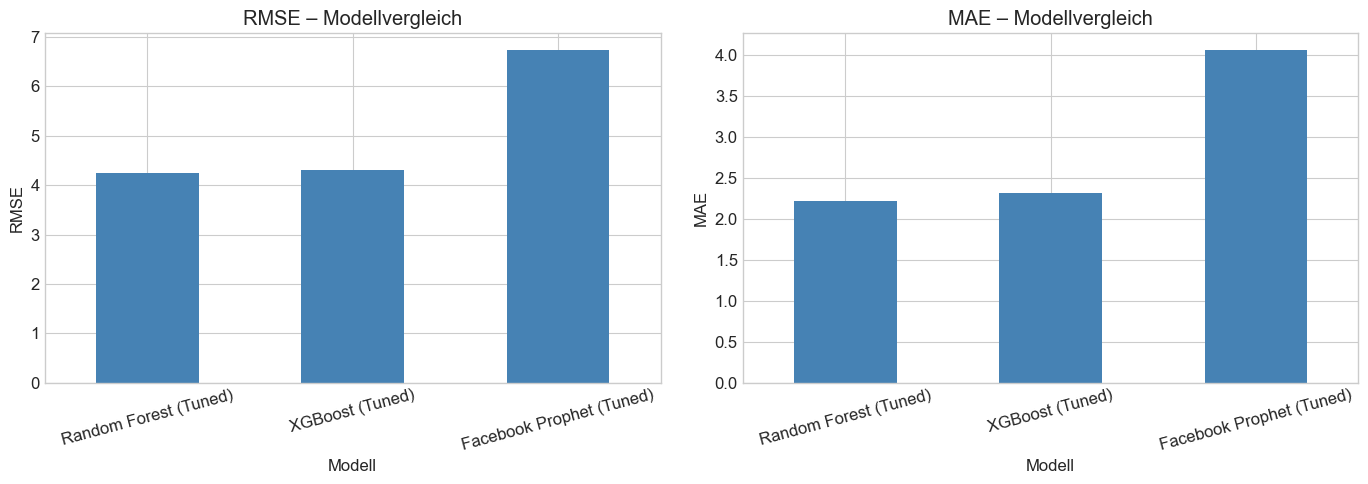

In [126]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['steelblue', 'darkorange', 'seagreen']

comparison[['RMSE']].plot(kind='bar', ax=axes[0], color=colors, legend=False)
axes[0].set_title('RMSE – Modellvergleich')
axes[0].set_ylabel('RMSE')
axes[0].tick_params(axis='x', rotation=15)

comparison[['MAE']].plot(kind='bar', ax=axes[1], color=colors, legend=False)
axes[1].set_title('MAE – Modellvergleich')
axes[1].set_ylabel('MAE')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

**Interpretation:** Die Balkendiagramme zeigen RMSE und MAE der drei getunten Modelle im direkten Vergleich. Kürzere Balken bedeuten geringere Fehler und damit bessere Vorhersagen. RMSE bestraft große Ausreißer stärker als MAE – wenn ein Modell beim RMSE deutlich schlechter abschneidet als beim MAE, hat es bei einzelnen Produkten besonders große Fehler gemacht.

### 7.2 Actual vs. Predicted – Ausgewählte Produkte

Wir wählen je ein Produkt aus jeder Risikogruppe und vergleichen die Vorhersagen aller drei Modelle.

Ausgewählte Beispielprodukte:
  hoch: Ananaskonserve, Erdbeerkonserve oder Ähnliches
  mittel: Blumenkohl, Wirsing oder anderer Kohl
  stabil: Antipasti auf Gemüsebasis, ohne Oliven


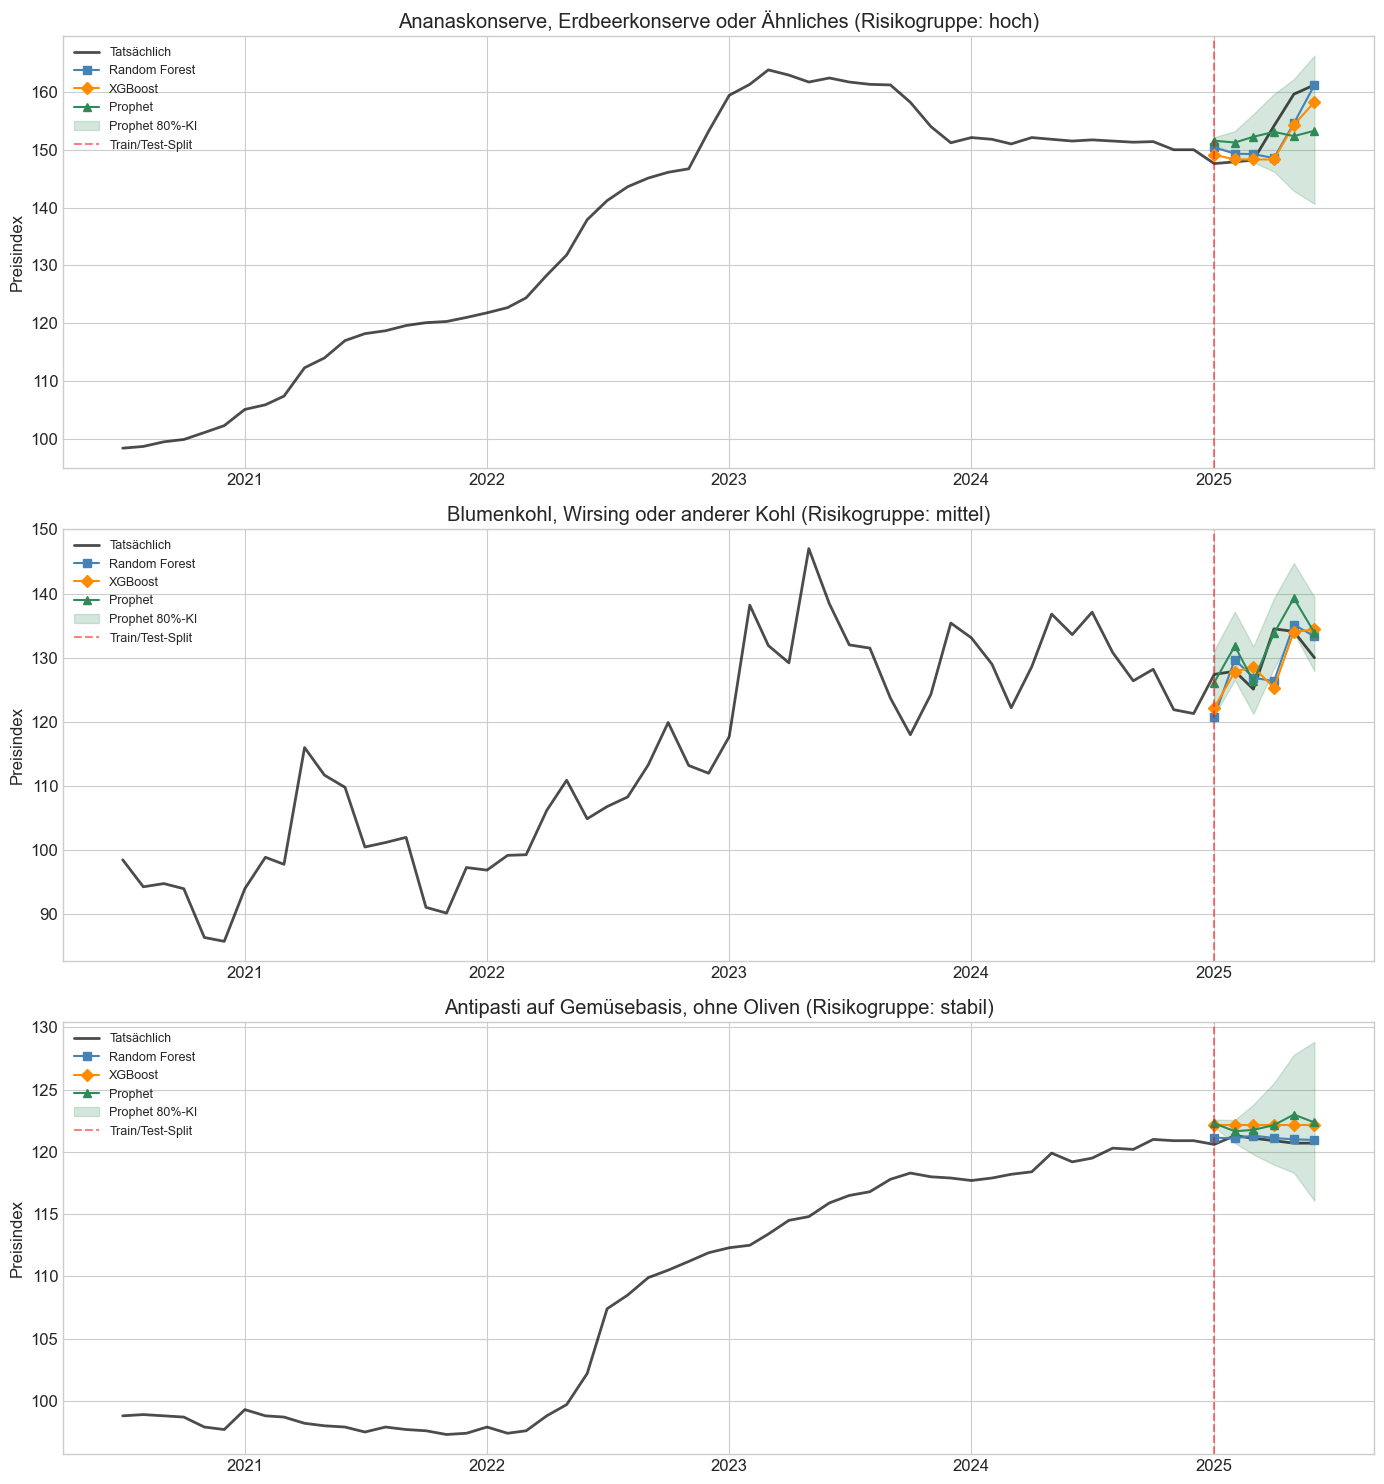

In [127]:
# Je ein Beispielprodukt pro Risikogruppe auswählen (aus Prophet-Ergebnissen)
example_products = {}
for gruppe in ['hoch', 'mittel', 'stabil']:
    for r in prophet_results:
        if produkt_risiko.get(r['Produkt']) == gruppe:
            example_products[gruppe] = r['Produkt']
            break

print("Ausgewählte Beispielprodukte:")
for gruppe, prod in example_products.items():
    print(f"  {gruppe}: {prod}")

fig, axes = plt.subplots(len(example_products), 1, figsize=(14, 5 * len(example_products)))

for idx, (gruppe, produkt) in enumerate(example_products.items()):
    ax = axes[idx]
    
    # Gesamte Zeitreihe
    prod_data = df_clean[df_clean['Produkt'] == produkt].sort_values('Datum')
    ax.plot(prod_data['Datum'], prod_data['Preisindex'], 'k-', label='Tatsächlich', linewidth=2, alpha=0.7)
    
    # RF & XGBoost Vorhersagen
    test_prod = test[test['Produkt'] == produkt].sort_values('Datum')
    if len(test_prod) > 0:
        test_idx = test_prod.index
        ax.plot(test_prod['Datum'], pd.Series(y_pred_rf, index=y_test.index)[test_idx], 
                's-', color='steelblue', label='Random Forest', markersize=6)
        ax.plot(test_prod['Datum'], pd.Series(y_pred_xgb, index=y_test.index)[test_idx], 
                'D-', color='darkorange', label='XGBoost', markersize=6)
    
    # Prophet Vorhersage
    for r in prophet_results:
        if r['Produkt'] == produkt:
            ax.plot(pd.to_datetime(r['dates']), r['y_pred'], 
                    '^-', color='seagreen', label='Prophet', markersize=6)
            ax.fill_between(pd.to_datetime(r['dates']), r['y_lower'], r['y_upper'], 
                           alpha=0.2, color='seagreen', label='Prophet 80%-KI')
            break
    
    ax.axvline(x=pd.Timestamp(cutoff_date), color='red', linestyle='--', alpha=0.5, label='Train/Test-Split')
    ax.set_title(f'{produkt} (Risikogruppe: {gruppe})')
    ax.set_ylabel('Preisindex')
    ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

**Interpretation:** Jeder Subplot zeigt die gesamte Preisindex-Zeitreihe eines Produkts (schwarze Linie) und die Vorhersagen aller drei Modelle im Testbereich (rechts der roten Linie). Die grüne Schattierung ist das Prophet-Konfidenzintervall – je schmaler es ist, desto sicherer ist Prophet in seiner Vorhersage. Liegen die farbigen Marker nahe an der schwarzen Linie, hat das Modell gut vorhergesagt.

### 7.3 Residuen-Analyse

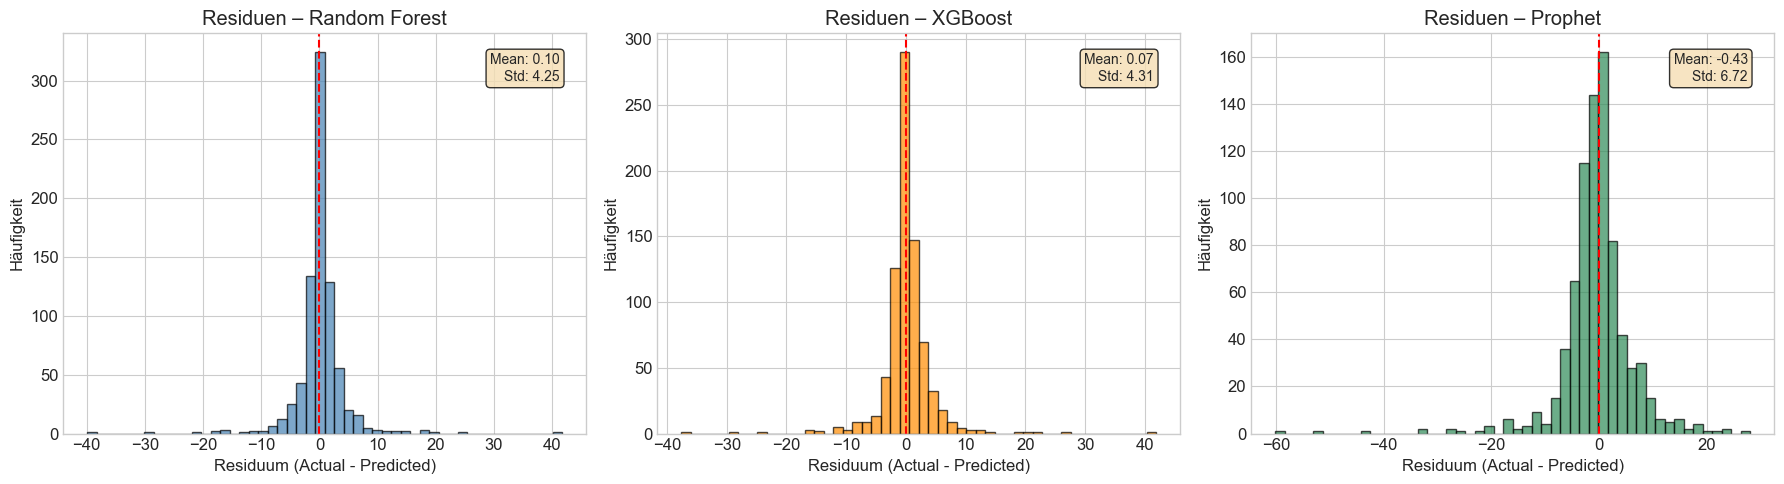

In [128]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

residuals = {
    'Random Forest': y_test.values - y_pred_rf,
    'XGBoost': y_test.values - y_pred_xgb,
    'Prophet': prophet_y_true - prophet_y_pred,
}

for ax, (name, res) in zip(axes, residuals.items()):
    ax.hist(res, bins=50, edgecolor='black', alpha=0.7, 
            color={'Random Forest': 'steelblue', 'XGBoost': 'darkorange', 'Prophet': 'seagreen'}[name])
    ax.axvline(x=0, color='red', linestyle='--')
    ax.set_title(f'Residuen – {name}')
    ax.set_xlabel('Residuum (Actual - Predicted)')
    ax.set_ylabel('Häufigkeit')
    ax.text(0.95, 0.95, f'Mean: {res.mean():.2f}\nStd: {res.std():.2f}', 
            transform=ax.transAxes, ha='right', va='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

**Interpretation:** Die Histogramme zeigen die Verteilung der Vorhersagefehler (Residuen = Actual − Predicted) pro Modell. Eine gute Verteilung ist schmal, symmetrisch und um Null zentriert. Ein Mean nahe 0 bedeutet kein systematischer Bias, eine kleine Standardabweichung (Std) bedeutet konsistent geringe Fehler. Schiefe oder breite Verteilungen deuten auf Probleme bei bestimmten Produktgruppen hin.

### 7.4 Feature Importance – Vergleich RF vs. XGBoost

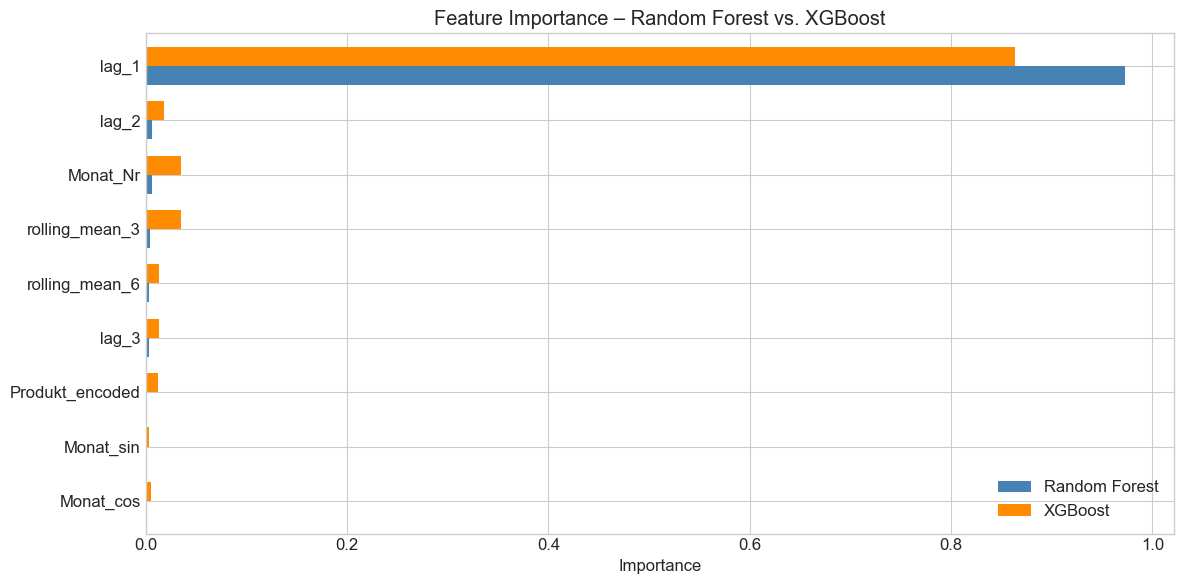

In [129]:
fi_compare = pd.DataFrame({
    'Random Forest': rf_importance,
    'XGBoost': xgb_importance,
}).sort_values('Random Forest', ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
fi_compare.plot(kind='barh', ax=ax, color=['steelblue', 'darkorange'], width=0.7)
ax.set_title('Feature Importance – Random Forest vs. XGBoost')
ax.set_xlabel('Importance')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Interpretation:** Dieses Diagramm vergleicht, welche Features Random Forest (blau) und XGBoost (orange) als wichtig einstufen. Stimmen beide Modelle überein (z.B. lag_1 dominiert bei beiden), ist die Erkenntnis robust. Unterschiede zeigen, dass die Modelle die Daten unterschiedlich nutzen – XGBoost gewichtet Features nach deren Beitrag zur Fehlerreduktion (Gain), Random Forest nach der Häufigkeit und Qualität der Splits.

### 7.5 Prophet – Komponentenzerlegung (Beispielprodukt)

Komponentenzerlegung für: Ananaskonserve, Erdbeerkonserve oder Ähnliches


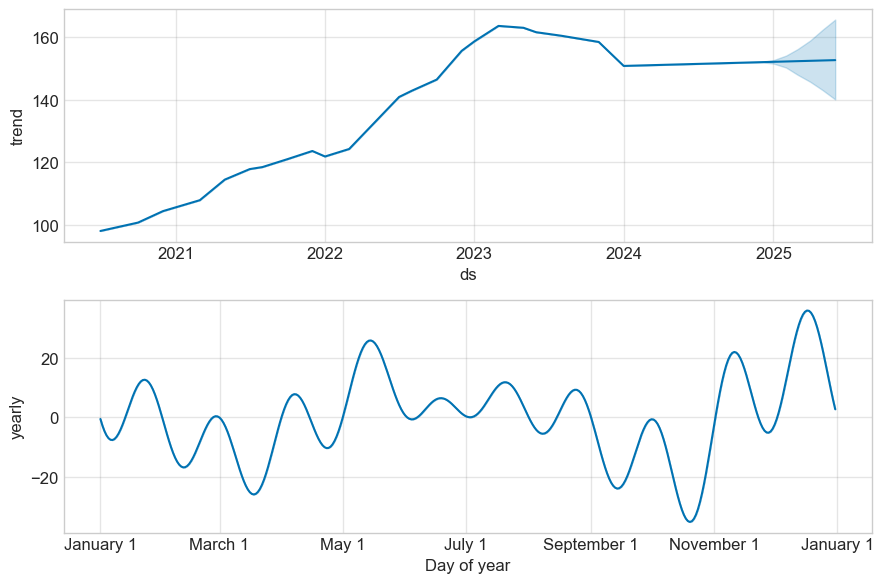

In [130]:
# Prophet-Komponentenzerlegung für ein Beispielprodukt
example_prod = list(example_products.values())[0]
if example_prod in prophet_forecasts:
    model, forecast, _, _ = prophet_forecasts[example_prod]
    print(f"Komponentenzerlegung für: {example_prod}")
    fig = model.plot_components(forecast)
    plt.tight_layout()
    plt.show()

**Interpretation:** Prophet zerlegt seine Vorhersage in zwei Komponenten: Der **Trend** zeigt die langfristige Preisentwicklung (z.B. Inflationsanstieg seit 2021). Die **Yearly Seasonality** zeigt wiederkehrende Muster innerhalb eines Jahres (z.B. saisonale Preisschwankungen bei Obst und Gemüse). Diese Zerlegung ist ein Alleinstellungsmerkmal von Prophet und macht die Vorhersage direkt interpretierbar.

## 8. Risikogruppen-Klassifikation

Zusätzlich zur Preisprognose untersuchen wir, ob sich Produkte anhand ihres Preisverhaltens in Risikogruppen (hoch / mittel / stabil) klassifizieren lassen. Dazu nutzen wir aggregierte Features pro Produkt.

=== Risikogruppen-Klassifikation: Random Forest ===

              precision    recall  f1-score   support

        hoch       1.00      1.00      1.00        14
      mittel       1.00      1.00      1.00        14
      stabil       1.00      1.00      1.00        14

    accuracy                           1.00        42
   macro avg       1.00      1.00      1.00        42
weighted avg       1.00      1.00      1.00        42

=== Risikogruppen-Klassifikation: XGBoost ===

              precision    recall  f1-score   support

        hoch       1.00      0.93      0.96        14
      mittel       0.93      1.00      0.97        14
      stabil       1.00      1.00      1.00        14

    accuracy                           0.98        42
   macro avg       0.98      0.98      0.98        42
weighted avg       0.98      0.98      0.98        42



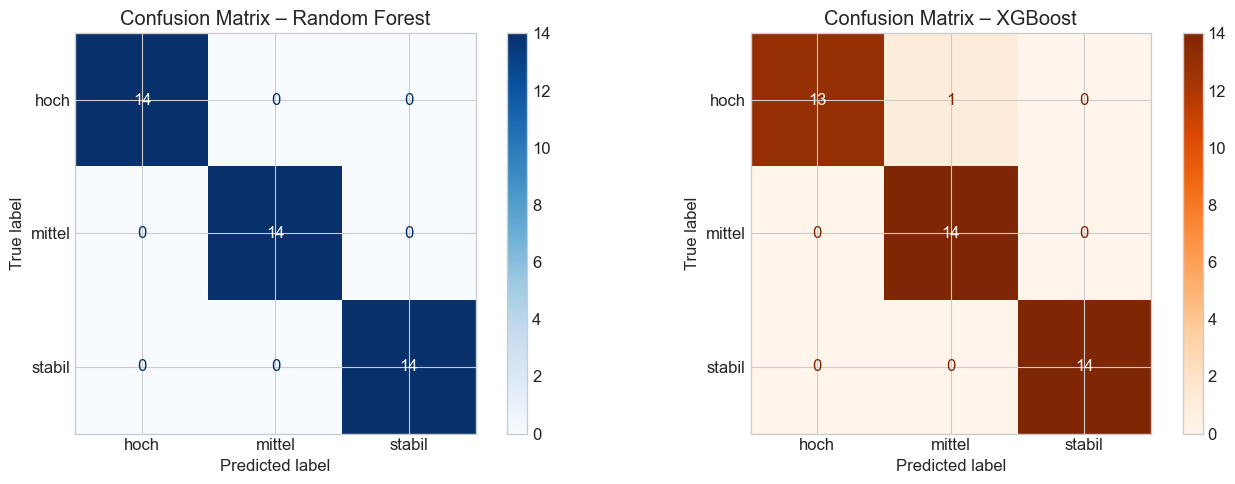

In [131]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Aggregierte Features pro Produkt berechnen
prod_features = df_clean.groupby('Produkt').agg(
    mean_price=('Preisindex', 'mean'),
    std_price=('Preisindex', 'std'),
    min_price=('Preisindex', 'min'),
    max_price=('Preisindex', 'max'),
    price_range=('Preisindex', lambda x: x.max() - x.min()),
    preisanstieg=('preisanstieg_pct', 'first'),
    mean_lag1=('lag_1', 'mean'),
    mean_rolling3=('rolling_mean_3', 'mean'),
).reset_index()

# Risikogruppe als Label
prod_labels = df_clean[['Produkt', 'Risikogruppe']].drop_duplicates()
prod_df = prod_features.merge(prod_labels, on='Produkt')

# Train/Test-Split (stratifiziert)
from sklearn.model_selection import train_test_split

clf_features = ['mean_price', 'std_price', 'min_price', 'max_price', 'price_range', 
                'preisanstieg', 'mean_lag1', 'mean_rolling3']

X_clf = prod_df[clf_features]
y_clf = prod_df['Risikogruppe']

X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.25, random_state=RANDOM_STATE, stratify=y_clf
)

# --- Modell 1: Random Forest Classifier ---
clf_rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
clf_rf.fit(X_clf_train, y_clf_train)
y_clf_pred_rf = clf_rf.predict(X_clf_test)

print("=== Risikogruppen-Klassifikation: Random Forest ===\n")
print(classification_report(y_clf_test, y_clf_pred_rf))

# --- Modell 2: XGBoost Classifier ---
# XGBoost benötigt numerische Labels – LabelEncoder wandelt die Strings um
le_clf = LabelEncoder()
y_clf_train_encoded = le_clf.fit_transform(y_clf_train)
y_clf_test_encoded = le_clf.transform(y_clf_test)

xgb_clf = xgb.XGBClassifier(
    n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1, verbosity=0,
    eval_metric='mlogloss'
)
xgb_clf.fit(X_clf_train, y_clf_train_encoded)
y_clf_pred_xgb_encoded = xgb_clf.predict(X_clf_test)
# Zurück in Textlabels umwandeln für die Auswertung
y_clf_pred_xgb = le_clf.inverse_transform(y_clf_pred_xgb_encoded)

print("=== Risikogruppen-Klassifikation: XGBoost ===\n")
print(classification_report(y_clf_test, y_clf_pred_xgb))

# --- Confusion Matrices nebeneinander ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(y_clf_test, y_clf_pred_rf, ax=axes[0], cmap='Blues')
axes[0].set_title('Confusion Matrix – Random Forest')

ConfusionMatrixDisplay.from_predictions(y_clf_test, y_clf_pred_xgb, ax=axes[1], cmap='Oranges')
axes[1].set_title('Confusion Matrix – XGBoost')

plt.tight_layout()
plt.show()

## 9. Sensitivitätsanalyse: Einfluss von Lag-12 auf die Vorhersagequalität

Bisher nutzen wir `lag_1`, `lag_2` und `lag_3` – also nur die kurzfristige Vergangenheit (1–3 Monate). Aber Lebensmittelpreise haben oft **jährliche Saisonalität**: Tomaten sind jeden Sommer günstiger, Heizkosten jeden Winter höher.

Ein `lag_12` (Preis vor genau 12 Monaten) könnte diese Saisonalität direkt abbilden – der Preis von Tomaten im Juli 2024 ist vermutlich ein guter Indikator für den Preis im Juli 2025.

**Der Trade-off:** Für `lag_12` brauchen wir mindestens 12 Monate Vorgeschichte pro Produkt. Das bedeutet wir verlieren mehr Trainingszeilen. Lohnt sich der Informationsgewinn trotzdem?

**Hinweis:** Diese Analyse betrifft nur Random Forest und XGBoost. Prophet wird hier nicht einbezogen, da es ein reines Zeitreihenmodell ist, das Saisonalität intern modelliert und keine handgefertigten Lag-Features benötigt.

In [132]:
# =============================================================================
# Schritt 1: lag_12 Feature erstellen
# =============================================================================
# Wir berechnen lag_12 pro Produkt: der Preisindex desselben Produkts
# vor genau 12 Monaten. Das fängt jährliche Saisonalität ein.
# =============================================================================

df_clean['lag_12'] = df_clean.groupby('Produkt')['Preisindex'].shift(12)

# Wie viele Zeilen verlieren wir zusätzlich durch lag_12?
lag12_nans = df_clean['lag_12'].isna().sum()
print(f"Zusätzliche NaN-Zeilen durch lag_12: {lag12_nans}")

# Neues bereinigtes Dataset: alle bisherigen Features + lag_12 ohne NaN
ml_features_lag12 = ml_features + ['lag_12']
df_lag12 = df_clean.dropna(subset=ml_features_lag12 + [target_col]).copy()

print(f"\nVergleich Datensatzgröße:")
print(f"  Ohne lag_12: {len(df_clean)} Zeilen")
print(f"  Mit  lag_12: {len(df_lag12)} Zeilen (verloren: {len(df_clean) - len(df_lag12)})")
print(f"  Verlust:     {(len(df_clean) - len(df_lag12)) / len(df_clean) * 100:.1f}%")

Zusätzliche NaN-Zeilen durch lag_12: 2016

Vergleich Datensatzgröße:
  Ohne lag_12: 9870 Zeilen
  Mit  lag_12: 7854 Zeilen (verloren: 2016)
  Verlust:     20.4%


In [133]:
# =============================================================================
# Schritt 2: Train/Test-Split mit lag_12 (gleicher zeitlicher Cutoff)
# =============================================================================

train_l12 = df_lag12[df_lag12['Datum'] < cutoff_date].copy()
test_l12 = df_lag12[df_lag12['Datum'] >= cutoff_date].copy()

X_train_l12 = train_l12[ml_features_lag12]
y_train_l12 = train_l12[target_col]
X_test_l12 = test_l12[ml_features_lag12]
y_test_l12 = test_l12[target_col]

print(f"Train: {len(train_l12)} Zeilen (vorher: {len(train)})")
print(f"Test:  {len(test_l12)} Zeilen (vorher: {len(test)})")
print(f"Features: {ml_features_lag12}")

Train: 7056 Zeilen (vorher: 9072)
Test:  798 Zeilen (vorher: 798)
Features: ['Monat_Nr', 'lag_1', 'lag_2', 'lag_3', 'rolling_mean_3', 'rolling_mean_6', 'Monat_sin', 'Monat_cos', 'Produkt_encoded', 'lag_12']


In [134]:
# =============================================================================
# Schritt 3: Random Forest & XGBoost mit lag_12 trainieren
# =============================================================================
# Wir nutzen die gleichen besten Hyperparameter aus dem Tuning,
# damit der Vergleich fair ist – nur das zusätzliche Feature ändert sich.
# =============================================================================

# Random Forest mit lag_12
rf_l12 = RandomForestRegressor(**rf_search.best_params_, random_state=RANDOM_STATE, n_jobs=-1)
rf_l12.fit(X_train_l12, y_train_l12)
y_pred_rf_l12 = rf_l12.predict(X_test_l12)

# XGBoost mit lag_12
xgb_l12 = xgb.XGBRegressor(**xgb_search.best_params_, random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
xgb_l12.fit(X_train_l12, y_train_l12)
y_pred_xgb_l12 = xgb_l12.predict(X_test_l12)

print("Training abgeschlossen: RF und XGBoost mit lag_12")

Training abgeschlossen: RF und XGBoost mit lag_12


In [135]:
# =============================================================================
# Schritt 4: Vergleich – mit vs. ohne lag_12
# =============================================================================
# WICHTIG: Für einen fairen Vergleich evaluieren wir die Modelle OHNE lag_12
# ebenfalls nur auf den Zeilen, die auch im lag_12-Testset vorhanden sind.
# Sonst vergleichen wir auf unterschiedlichen Daten.
# =============================================================================

# RF und XGBoost ohne lag_12, aber auf dem gleichen (kleineren) Datensatz
rf_fair = RandomForestRegressor(**rf_search.best_params_, random_state=RANDOM_STATE, n_jobs=-1)
rf_fair.fit(train_l12[ml_features], y_train_l12)
y_pred_rf_fair = rf_fair.predict(test_l12[ml_features])

xgb_fair = xgb.XGBRegressor(**xgb_search.best_params_, random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
xgb_fair.fit(train_l12[ml_features], y_train_l12)
y_pred_xgb_fair = xgb_fair.predict(test_l12[ml_features])

# Vergleichstabelle
comparison_lag12 = pd.DataFrame([
    calc_metrics(y_test_l12, y_pred_rf_fair, 'RF ohne lag_12'),
    calc_metrics(y_test_l12, y_pred_rf_l12, 'RF mit lag_12'),
    calc_metrics(y_test_l12, y_pred_xgb_fair, 'XGBoost ohne lag_12'),
    calc_metrics(y_test_l12, y_pred_xgb_l12, 'XGBoost mit lag_12'),
]).set_index('Modell')

comparison_lag12.style.format('{:.4f}')

,RMSE,MAE,R²,MAPE
Modell,,,,
RF ohne lag_12,4.2801,2.2220,0.9268,0.0163
RF mit lag_12,4.2428,2.2477,0.9280,0.0165
XGBoost ohne lag_12,4.3473,2.3729,0.9244,0.0175
XGBoost mit lag_12,4.2252,2.3790,0.9286,0.0176


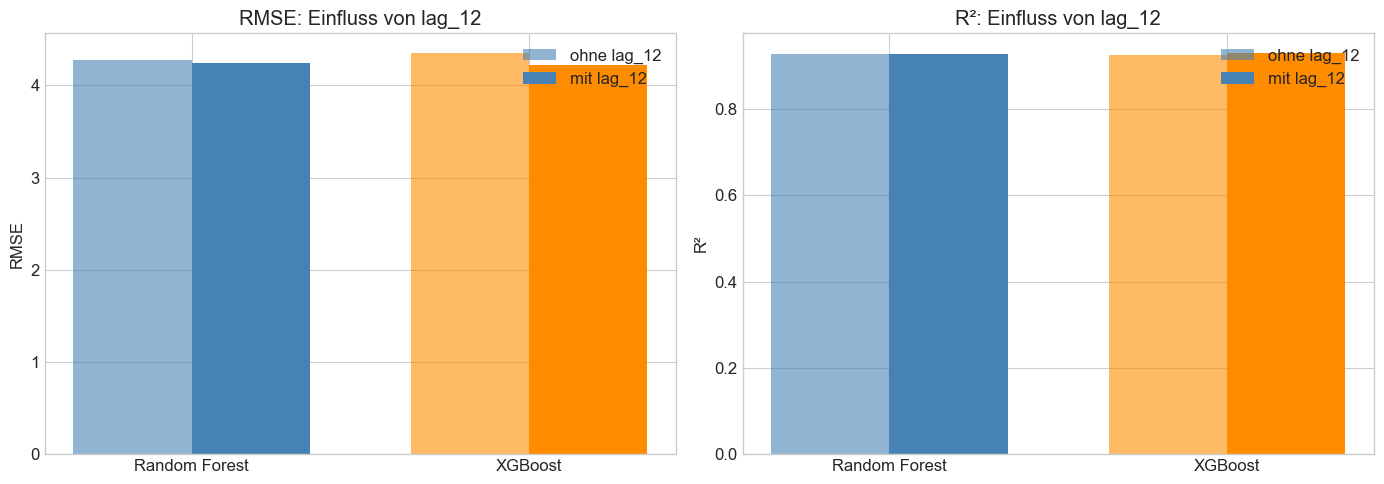


Veränderung durch lag_12:
  Random Forest: RMSE -0.87% (↓ besser)
  XGBoost: RMSE -2.81% (↓ besser)


In [136]:
# =============================================================================
# Schritt 5: Visualisierung – Verbesserung/Verschlechterung durch lag_12
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = ['Random Forest', 'XGBoost']
rmse_ohne = [
    comparison_lag12.loc['RF ohne lag_12', 'RMSE'],
    comparison_lag12.loc['XGBoost ohne lag_12', 'RMSE'],
]
rmse_mit = [
    comparison_lag12.loc['RF mit lag_12', 'RMSE'],
    comparison_lag12.loc['XGBoost mit lag_12', 'RMSE'],
]

x = np.arange(len(models))
width = 0.35

axes[0].bar(x - width/2, rmse_ohne, width, label='ohne lag_12', color=['steelblue', 'darkorange'], alpha=0.6)
axes[0].bar(x + width/2, rmse_mit, width, label='mit lag_12', color=['steelblue', 'darkorange'], alpha=1.0)
axes[0].set_ylabel('RMSE')
axes[0].set_title('RMSE: Einfluss von lag_12')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].legend()

r2_ohne = [
    comparison_lag12.loc['RF ohne lag_12', 'R²'],
    comparison_lag12.loc['XGBoost ohne lag_12', 'R²'],
]
r2_mit = [
    comparison_lag12.loc['RF mit lag_12', 'R²'],
    comparison_lag12.loc['XGBoost mit lag_12', 'R²'],
]

axes[1].bar(x - width/2, r2_ohne, width, label='ohne lag_12', color=['steelblue', 'darkorange'], alpha=0.6)
axes[1].bar(x + width/2, r2_mit, width, label='mit lag_12', color=['steelblue', 'darkorange'], alpha=1.0)
axes[1].set_ylabel('R²')
axes[1].set_title('R²: Einfluss von lag_12')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models)
axes[1].legend()

plt.tight_layout()
plt.show()

# Prozentualer Unterschied
print("\nVeränderung durch lag_12:")
for m in models:
    prefix = 'RF' if m == 'Random Forest' else 'XGBoost'
    rmse_o = comparison_lag12.loc[f'{prefix} ohne lag_12', 'RMSE']
    rmse_m = comparison_lag12.loc[f'{prefix} mit lag_12', 'RMSE']
    change = (rmse_m - rmse_o) / rmse_o * 100
    symbol = "↓ besser" if change < 0 else "↑ schlechter"
    print(f"  {m}: RMSE {change:+.2f}% ({symbol})")

### 9.1 Prognose-Plots: Gurken & Paprika – mit vs. ohne lag_12

Für zwei saisonale Produkte (Gurken, Paprika) vergleichen wir die Vorhersagen von Random Forest und XGBoost jeweils **ohne** und **mit** lag_12-Feature. So wird sichtbar, ob der Jahres-Lag die Prognosequalität bei diesen Produkten verbessert.

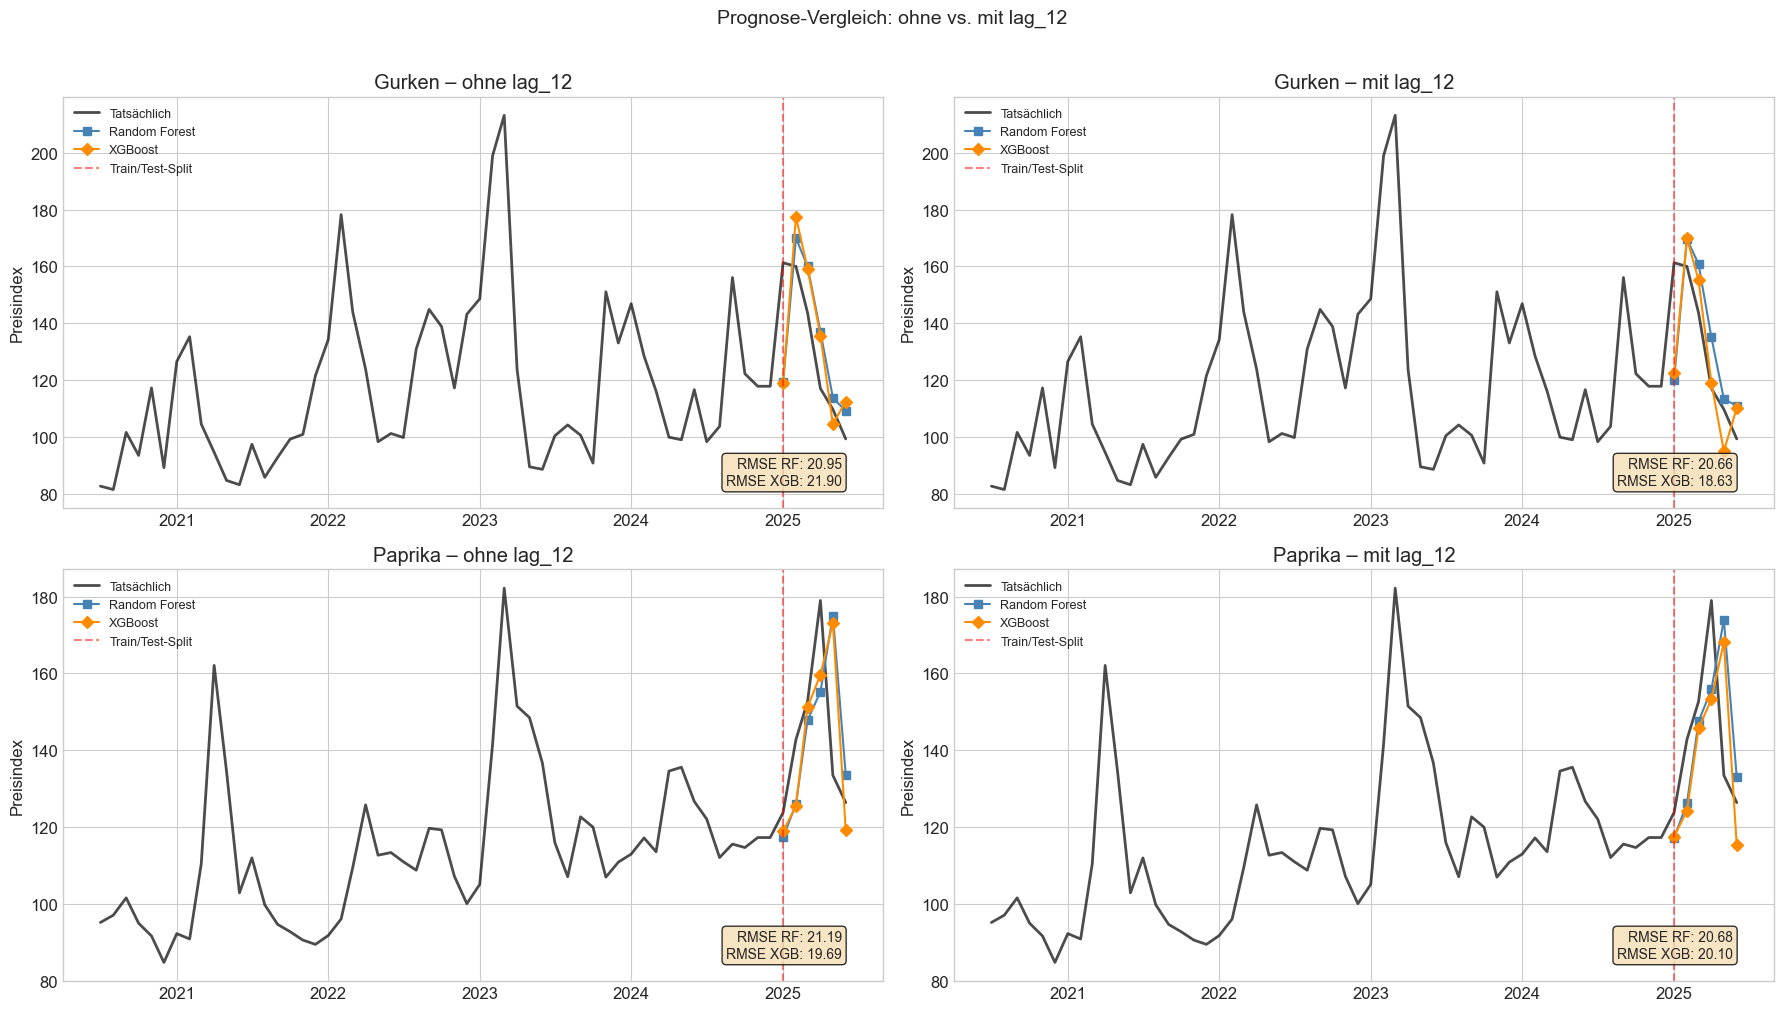

In [137]:
forecast_products = ['Gurken', 'Paprika']

fig, axes = plt.subplots(len(forecast_products), 2, figsize=(18, 5 * len(forecast_products)))

for row, produkt in enumerate(forecast_products):
    # --- Daten für dieses Produkt ---
    prod_full = df_clean[df_clean['Produkt'] == produkt].sort_values('Datum')
    
    # Ohne lag_12
    test_prod = test_l12[test_l12['Produkt'] == produkt].sort_values('Datum')
    train_prod = train_l12[train_l12['Produkt'] == produkt].sort_values('Datum')
    
    if len(test_prod) == 0:
        print(f"⚠ {produkt} nicht im lag_12-Testset enthalten, überspringe.")
        continue
    
    test_idx = test_prod.index
    
    # Vorhersagen ohne lag_12
    pred_rf_ohne = rf_fair.predict(test_prod[ml_features])
    pred_xgb_ohne = xgb_fair.predict(test_prod[ml_features])
    
    # Vorhersagen mit lag_12
    pred_rf_mit = rf_l12.predict(test_prod[ml_features_lag12])
    pred_xgb_mit = xgb_l12.predict(test_prod[ml_features_lag12])
    
    # --- Plot 1: Ohne lag_12 ---
    ax1 = axes[row, 0]
    ax1.plot(prod_full['Datum'], prod_full['Preisindex'], 'k-', label='Tatsächlich', linewidth=2, alpha=0.7)
    ax1.plot(test_prod['Datum'], pred_rf_ohne, 's-', color='steelblue', label='Random Forest', markersize=6)
    ax1.plot(test_prod['Datum'], pred_xgb_ohne, 'D-', color='darkorange', label='XGBoost', markersize=6)
    ax1.axvline(x=pd.Timestamp(cutoff_date), color='red', linestyle='--', alpha=0.5, label='Train/Test-Split')
    ax1.set_title(f'{produkt} – ohne lag_12')
    ax1.set_ylabel('Preisindex')
    ax1.legend(loc='upper left', fontsize=9)
    
    # RMSE anzeigen
    rmse_rf_o = np.sqrt(mean_squared_error(test_prod[target_col], pred_rf_ohne))
    rmse_xgb_o = np.sqrt(mean_squared_error(test_prod[target_col], pred_xgb_ohne))
    ax1.text(0.95, 0.05, f'RMSE RF: {rmse_rf_o:.2f}\nRMSE XGB: {rmse_xgb_o:.2f}',
             transform=ax1.transAxes, ha='right', va='bottom', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    # --- Plot 2: Mit lag_12 ---
    ax2 = axes[row, 1]
    ax2.plot(prod_full['Datum'], prod_full['Preisindex'], 'k-', label='Tatsächlich', linewidth=2, alpha=0.7)
    ax2.plot(test_prod['Datum'], pred_rf_mit, 's-', color='steelblue', label='Random Forest', markersize=6)
    ax2.plot(test_prod['Datum'], pred_xgb_mit, 'D-', color='darkorange', label='XGBoost', markersize=6)
    ax2.axvline(x=pd.Timestamp(cutoff_date), color='red', linestyle='--', alpha=0.5, label='Train/Test-Split')
    ax2.set_title(f'{produkt} – mit lag_12')
    ax2.set_ylabel('Preisindex')
    ax2.legend(loc='upper left', fontsize=9)
    
    # RMSE anzeigen
    rmse_rf_m = np.sqrt(mean_squared_error(test_prod[target_col], pred_rf_mit))
    rmse_xgb_m = np.sqrt(mean_squared_error(test_prod[target_col], pred_xgb_mit))
    ax2.text(0.95, 0.05, f'RMSE RF: {rmse_rf_m:.2f}\nRMSE XGB: {rmse_xgb_m:.2f}',
             transform=ax2.transAxes, ha='right', va='bottom', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.suptitle('Prognose-Vergleich: ohne vs. mit lag_12', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 10. Fazit & Zusammenfassung

In [138]:
print("=" * 70)
print("ZUSAMMENFASSUNG – Modellvergleich Lebensmittelpreisprognose")
print("=" * 70)
print()
print(comparison.to_string())
print()
print("-" * 70)

best_model = comparison['RMSE'].idxmin()
print(f"\nBestes Modell (nach RMSE): {best_model}")
print(f"  RMSE: {comparison.loc[best_model, 'RMSE']:.4f}")
print(f"  R²:   {comparison.loc[best_model, 'R²']:.4f}")
print()
print("Kernerkenntnisse:")
print("  - Lag-Features (insbes. lag_1) sind die wichtigsten Prädiktoren")
print("  - Stabile Produkte lassen sich besser vorhersagen als volatile")
print("  - Prophet liefert zusätzlich interpretierbare Komponentenzerlegung")
print("  - Die Risikogruppen-Klassifikation zeigt, dass Preisverhalten")
print("    gut zur Einordnung von Produkten nutzbar ist")

ZUSAMMENFASSUNG – Modellvergleich Lebensmittelpreisprognose

                              RMSE       MAE        R²      MAPE
Modell                                                          
Random Forest (Tuned)     4.249396  2.219892  0.927803  0.016300
XGBoost (Tuned)           4.314739  2.313990  0.925566  0.016859
Facebook Prophet (Tuned)  6.736938  4.066488  0.818537  0.029322

----------------------------------------------------------------------

Bestes Modell (nach RMSE): Random Forest (Tuned)
  RMSE: 4.2494
  R²:   0.9278

Kernerkenntnisse:
  - Lag-Features (insbes. lag_1) sind die wichtigsten Prädiktoren
  - Stabile Produkte lassen sich besser vorhersagen als volatile
  - Prophet liefert zusätzlich interpretierbare Komponentenzerlegung
  - Die Risikogruppen-Klassifikation zeigt, dass Preisverhalten
    gut zur Einordnung von Produkten nutzbar ist
